In [4]:
from spark_config import get_spark_session

spark = get_spark_session(app_name="ethereum_EDA")


26/05/07 00:26:01 WARN Utils: Your hostname, khanhdo-VMware-Virtual-Platform resolves to a loopback address: 127.0.1.1; using 192.168.118.128 instead (on interface ens33)
26/05/07 00:26:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/07 00:26:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [5]:
import pyspark.sql.functions as F
from pyspark.sql import Window

In [6]:
df_real_user_portfolios = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/real_user_portfolios")
df_real_user_portfolios.show(5)

+--------------------+--------------------+--------------------+--------+-------------------+-----------+
|        user_address|       token_address|             balance|tx_count|        last_active|is_contract|
+--------------------+--------------------+--------------------+--------+-------------------+-----------+
|0x00000000fff16d2...|0xdac17f958d2ee52...|           71.203482|       2|2026-04-28 01:37:59|      false|
|0x00000000fff16d2...|0xc02aaa39b223fe8...|  2.0000001514545227|       8|2026-04-28 01:54:47|      false|
|0x00006566a3158a6...|0xdac17f958d2ee52...|0.001000000000000...|       2|2026-02-08 10:13:59|      false|
|0x0001915c9c3d291...|0xdac17f958d2ee52...|2.981555974335137...|      34|2026-03-18 17:17:11|      false|
|0x000191bbf5a21d8...|0xdac17f958d2ee52...|           22.103434|       1|2026-02-22 12:26:47|      false|
+--------------------+--------------------+--------------------+--------+-------------------+-----------+
only showing top 5 rows



In [7]:
# Dem so token ma moi user so huu, tong so luong giao dich 
df_user_token_count = (
    df_real_user_portfolios
    .groupBy("user_address")
    .agg(
        F.countDistinct("token_address").alias("token_count"),
        F.sum("tx_count").alias("total_tx_count"),
        F.count("*").alias("portfolio_rows")
    )
    .orderBy(F.desc("token_count")).cache()
)

df_user_token_count.show(20, truncate=False)
print("So user:", df_user_token_count.count())

26/05/07 00:26:16 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


+------------------------------------------+-----------+--------------+--------------+
|user_address                              |token_count|total_tx_count|portfolio_rows|
+------------------------------------------+-----------+--------------+--------------+
|0x97e7e0b66c5d32fb873be6455557e4342f378477|395        |546           |395           |
|0x91f7ef5aae179299aa48b554e8049e42f1b1dcc4|279        |1067          |279           |
|0x5aafc1f252d544f744d17a4e734afd6efc47ede4|240        |4080          |240           |
|0x745429e5660eefec27d38e039b5c9b42076dbffc|145        |434           |145           |
|0xad01c20d5886137e056775af56915de824c8fce5|139        |1218          |139           |
|0xc06ebbefd94032b85424d51906e2a335efae264b|93         |1051          |93            |
|0x000000000000000000000000000000000000dead|89         |1092          |89            |
|0xb4f34d09124b8c9712957b76707b42510041ecbb|84         |319           |84            |
|0xb837c86126afd947f9eb20253810bb4b9a906109

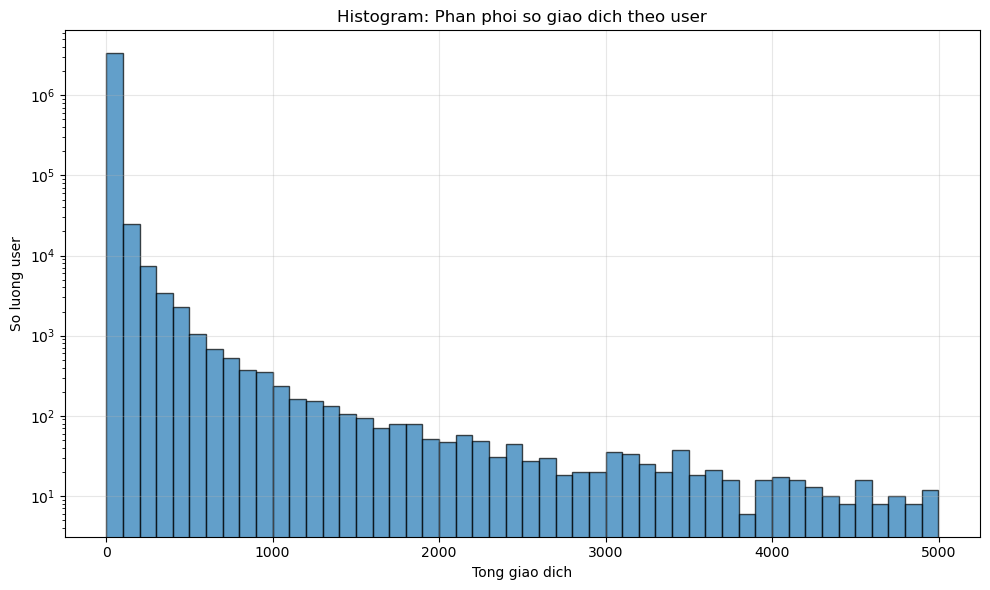

In [8]:
# Ve histogram phan phoi so giao dich theo user

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_pandas = df_user_token_count.toPandas().sort_values("total_tx_count", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_pandas["total_tx_count"], bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel("Tong giao dich")
ax.set_ylabel("So luong user")
ax.set_title("Histogram: Phan phoi so giao dich theo user")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


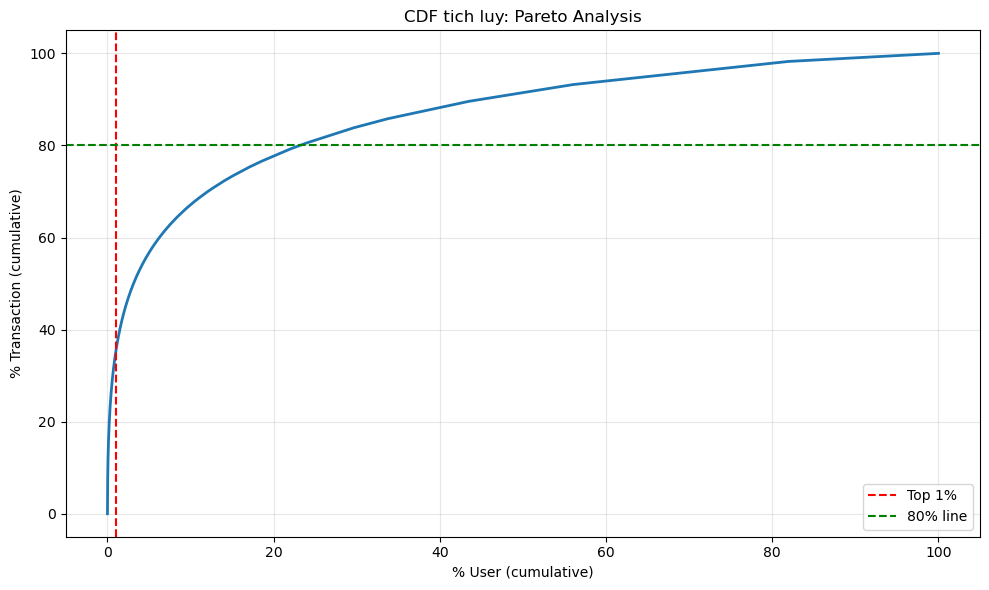

In [9]:
# CDF tich luy

sorted_tx = np.sort(df_pandas["total_tx_count"].values)[::-1]
cum_sum = np.cumsum(sorted_tx)
cum_pct = cum_sum / cum_sum[-1]
user_pct = np.arange(1, len(sorted_tx) + 1) / len(sorted_tx)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(user_pct * 100, cum_pct * 100, linewidth=2)
ax.axvline(1, color='red', linestyle='--', label='Top 1%')
ax.axhline(80, color='green', linestyle='--', label='80% line')
ax.set_xlabel("% User (cumulative)")
ax.set_ylabel("% Transaction (cumulative)")
ax.set_title("CDF tich luy: Pareto Analysis")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Nhận xét 2 biểu đồ

### 1. Histogram - Phân phối số giao dịch theo user
- Phân phối lệch phải rất mạnh: đa số user chỉ có ít giao dịch, trong khi một nhóm nhỏ user có số giao dịch rất cao.
- Dữ liệu có dạng heavy-tail rõ rệt, nên trục log giúp nhìn thấy tốt hơn phần đuôi phân phối.
- Điều này cho thấy hành vi giao dịch tập trung vào một số ít user hoạt động mạnh.

### 2. CDF tích lũy
- Đường cong tăng nhanh ở đoạn đầu, cho thấy phần lớn tổng giao dịch đến từ một tỷ lệ nhỏ user.
- Top 1% user đóng góp khoảng 38% tổng giao dịch, phản ánh mức độ tập trung cao.
- Khoảng 15-20% user đã tạo ra gần 80% tổng giao dịch, đúng với xu hướng Pareto.
- Kết quả này cho thấy dữ liệu phân hóa mạnh giữa nhóm user hoạt động nhẹ và nhóm user hoạt động dày.

## Lập ma trận User x Token


In [10]:
# Tạo ma trận User x Token (dùng balance làm giá trị)
# mapping user_address -> user_id
df_user_map = (
    df_real_user_portfolios
    .select("user_address")
    .distinct()
    .orderBy("user_address")
    .withColumn("user_id", F.row_number().over(Window.orderBy("user_address")))
)

# Tạo mapping token_address -> token_id
df_token_map = (
    df_real_user_portfolios
    .select("token_address")
    .distinct()
    .orderBy("token_address")
    .withColumn("token_id", F.row_number().over(Window.orderBy("token_address")))
)

num_users = df_user_map.count()
num_tokens = df_token_map.count()

# Join với dữ liệu gốc để lấy user_id và token_id
df_indexed = (
    df_real_user_portfolios
    .join(df_user_map, on="user_address", how="left")
    .join(df_token_map, on="token_address", how="left")
    .select("user_id", "token_id", "balance", "tx_count")
)

num_entries = df_indexed.count()  # Số phần tử khác 0

print(f"Số user: {num_users}")
print(f"Số token: {num_tokens}")
print(f"Số phần tử (entries): {num_entries}")

# Tính ma trận kích thước
total_elements = num_users * num_tokens
sparsity = (1 - num_entries / total_elements) * 100

print(f"\nKích thước ma trận: {num_users} x {num_tokens} = {total_elements:,} phần tử")
print(f"Độ thưa (Sparsity): {sparsity:.4f}%")


Số user: 3378007
Số token: 1910
Số phần tử (entries): 3427540

Kích thước ma trận: 3378007 x 1910 = 6,451,993,370 phần tử
Độ thưa (Sparsity): 99.9469%


## Thử lọc ma trân theo điều kiện: user activity + token popularity muc tiêu giảm sparsity và vẫn giữ đủ dữ liệu huấn luyện

In [11]:
df_real_user_portfolios = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/real_user_portfolios")

In [10]:
user_thresholds = [10, 20, 50]
token_thresholds = [10, 20, 50]

user_tx = (
    df_real_user_portfolios
    .groupBy("user_address")
    .agg(F.sum("tx_count").alias("total_tx"))
)

token_holders = (
    df_real_user_portfolios
    .groupBy("token_address")
    .agg(F.countDistinct("user_address").alias("num_holders"))
)

df_scored = (
    df_real_user_portfolios
    .join(user_tx, on="user_address", how="left")
    .join(token_holders, on="token_address", how="left")
    .select("user_address", "token_address", "total_tx", "num_holders")
    .cache()
)
_ = df_scored.count()

results = []

for min_tx in user_thresholds:
    for min_holders in token_thresholds:
        df_combined = df_scored.filter(
            (F.col("total_tx") >= min_tx) & (F.col("num_holders") >= min_holders)
        )

        metrics = df_combined.agg(
            F.count("*").alias("entries"),
            F.countDistinct("user_address").alias("users"),
            F.countDistinct("token_address").alias("tokens")
        ).first()

        n_entries = int(metrics["entries"])
        n_users = int(metrics["users"])
        n_tokens = int(metrics["tokens"])

        total_cells = n_users * n_tokens
        sparsity_combined = (1 - n_entries / total_cells) * 100 if total_cells > 0 else 100.0

        results.append({
            "min_tx": min_tx,
            "min_holders": min_holders,
            "users": n_users,
            "tokens": n_tokens,
            "entries": n_entries,
            "sparsity_pct": round(sparsity_combined, 4)
        })

results_sorted = sorted(results, key=lambda x: x["sparsity_pct"])
print("Bang so sanh loc ket hop (sap xep theo sparsity tang dan):")
for r in results_sorted:
    print(
        f"- min_tx>={r['min_tx']:2d}, min_holders>={r['min_holders']:2d} "
        f"| users={r['users']:,}, tokens={r['tokens']:,}, entries={r['entries']:,} "
        f"| sparsity={r['sparsity_pct']:.4f}%"
    )




Bang so sanh loc ket hop (sap xep theo sparsity tang dan):
- min_tx>=50, min_holders>=50 | users=97,610, tokens=162, entries=109,938 | sparsity=99.3048%
- min_tx>=20, min_holders>=50 | users=271,048, tokens=166, entries=290,015 | sparsity=99.3554%
- min_tx>=10, min_holders>=50 | users=567,593, tokens=167, entries=593,864 | sparsity=99.3735%
- min_tx>=50, min_holders>=20 | users=97,614, tokens=234, entries=110,324 | sparsity=99.5170%
- min_tx>=20, min_holders>=20 | users=271,077, tokens=241, entries=290,580 | sparsity=99.5552%
- min_tx>=10, min_holders>=20 | users=567,669, tokens=245, entries=594,592 | sparsity=99.5725%
- min_tx>=50, min_holders>=10 | users=97,618, tokens=316, entries=110,593 | sparsity=99.6415%
- min_tx>=20, min_holders>=10 | users=271,096, tokens=331, entries=290,954 | sparsity=99.6758%
- min_tx>=10, min_holders>=10 | users=567,704, tokens=339, entries=595,058 | sparsity=99.6908%


In [12]:
# Thử lọc user theo số lượng token mà họ cầm

base = "/home/khanhdo/Documents/project/bigdata_mining/data_processed"
df_real_user_portfolios = spark.read.parquet(f"{base}/real_user_portfolios")

# Tính số token khác nhau mà mỗi user cầm
user_token_count = (
    df_real_user_portfolios
    .groupBy("user_address")
    .agg(F.countDistinct("token_address").alias("num_tokens"))
)

# Tính số holders cho mỗi token
token_holders = (
    df_real_user_portfolios
    .groupBy("token_address")
    .agg(F.countDistinct("user_address").alias("num_holders"))
)

# Join để có đủ thông tin
df_scored_token_based = (
    df_real_user_portfolios
    .join(user_token_count, on="user_address", how="left")
    .join(token_holders, on="token_address", how="left")
    .select("user_address", "token_address", "num_tokens", "num_holders")
    .cache()
)

# Thử các ngưỡng token count
min_tokens_list = [2, 3, 5, 10, 20]  # User phải cầm tối thiểu N token
min_holders_list = [10, 20, 50]  # Token phải có tối thiểu N holders

results_token_based = []

for min_tokens in min_tokens_list:
    for min_holders in min_holders_list:
        df_filtered = df_scored_token_based.filter(
            (F.col("num_tokens") >= min_tokens) & (F.col("num_holders") >= min_holders)
        )
        
        metrics = df_filtered.agg(
            F.count("*").alias("entries"),
            F.countDistinct("user_address").alias("users"),
            F.countDistinct("token_address").alias("tokens")
        ).first()
        
        n_entries = int(metrics["entries"])
        n_users = int(metrics["users"])
        n_tokens = int(metrics["tokens"])
        
        total_cells = n_users * n_tokens
        sparsity = (1 - n_entries / total_cells) * 100 if total_cells > 0 else 100.0
        
        results_token_based.append({
            "min_tokens": min_tokens,
            "min_holders": min_holders,
            "users": n_users,
            "tokens": n_tokens,
            "entries": n_entries,
            "sparsity_pct": round(sparsity, 4)
        })

results_sorted = sorted(results_token_based, key=lambda x: x["sparsity_pct"])
print("Bảng so sánh lọc theo token count + holders (sắp xếp theo sparsity tăng dần):")
print("=" * 100)
for r in results_sorted:
    print(
        f"min_tokens>={r['min_tokens']:2d}, min_holders>={r['min_holders']:2d} "
        f"| users={r['users']:>6,}, tokens={r['tokens']:>6,}, entries={r['entries']:>10,} "
        f"| sparsity={r['sparsity_pct']:>7.4f}%"
    )


Bảng so sánh lọc theo token count + holders (sắp xếp theo sparsity tăng dần):
min_tokens>=20, min_holders>=50 | users=   106, tokens=   156, entries=     2,963 | sparsity=82.0815%
min_tokens>=20, min_holders>=20 | users=   106, tokens=   224, entries=     3,229 | sparsity=86.4008%
min_tokens>=20, min_holders>=10 | users=   107, tokens=   295, entries=     3,435 | sparsity=89.1177%
min_tokens>=10, min_holders>=50 | users=   374, tokens=   159, entries=     6,126 | sparsity=89.6983%
min_tokens>=10, min_holders>=20 | users=   376, tokens=   227, entries=     6,484 | sparsity=92.4032%
min_tokens>=10, min_holders>=10 | users=   377, tokens=   306, entries=     6,754 | sparsity=94.1454%
min_tokens>= 5, min_holders>=50 | users= 1,322, tokens=   160, entries=    11,672 | sparsity=94.4818%
min_tokens>= 5, min_holders>=20 | users= 1,325, tokens=   229, entries=    12,176 | sparsity=95.9871%
min_tokens>= 5, min_holders>=10 | users= 1,328, tokens=   310, entries=    12,524 | sparsity=96.9578%
min_

In [13]:
# Lọc cố định theo cấu hình: min_tokens >= 2, min_holders >= 50

df_filtered_2_50 = df_scored_token_based.filter(
    (F.col("num_tokens") >= 2) & (F.col("num_holders") >= 50)
)

metrics_2_50 = df_filtered_2_50.agg(
    F.count("*").alias("entries"),
    F.countDistinct("user_address").alias("users"),
    F.countDistinct("token_address").alias("tokens")
).first()

filtered_users = int(metrics_2_50["users"])
filtered_tokens = int(metrics_2_50["tokens"])
filtered_entries = int(metrics_2_50["entries"])
filtered_sparsity = (1 - filtered_entries / (filtered_users * filtered_tokens)) * 100 if filtered_users * filtered_tokens > 0 else 100.0

print("Filter config: min_tokens >= 2, min_holders >= 50")
print(f"Users: {filtered_users:,}")
print(f"Tokens: {filtered_tokens:,}")
print(f"Entries: {filtered_entries:,}")
print(f"Sparsity: {filtered_sparsity:.4f}%")

# Lưu dataset đã lọc để dùng cho recommendation
output_dir_filtered_2_50 = "/home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token"
df_filtered_2_50.write.mode("overwrite").parquet(output_dir_filtered_2_50)
print(f"Saved filtered dataset to: {output_dir_filtered_2_50}")

Filter config: min_tokens >= 2, min_holders >= 50
Users: 32,621
Tokens: 167
Entries: 78,559
Sparsity: 98.5579%
Saved filtered dataset to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token


In [14]:
df_filtered_2_50.show(10)

+--------------------+--------------------+----------+-----------+
|        user_address|       token_address|num_tokens|num_holders|
+--------------------+--------------------+----------+-----------+
|0x00000000fff16d2...|0xdac17f958d2ee52...|         2|    3133658|
|0x00000000fff16d2...|0xc02aaa39b223fe8...|         2|      85060|
|0x004d8876b4e4ced...|0x514910771af9ca6...|         2|      62930|
|0x004d8876b4e4ced...|0x4a220e6096b25ea...|         2|      12036|
|0x01bc8aad1069318...|0x2260fac5e5542a7...|         2|      31311|
|0x01bc8aad1069318...|0x514910771af9ca6...|         2|      62930|
|0x02a22b37f63e2b6...|0xa0b73e1ff0b8091...|         2|       4963|
|0x02a22b37f63e2b6...|0x0f5d2fb29fb7d3c...|         2|       2890|
|0x02a2a3d39d6bd43...|0x2260fac5e5542a7...|         2|      31311|
|0x02a2a3d39d6bd43...|0xdac17f958d2ee52...|         2|    3133658|
+--------------------+--------------------+----------+-----------+
only showing top 10 rows



### Tạo map user_id và token_id 

In [15]:
base = "/home/khanhdo/Documents/project/bigdata_mining/data_processed"

# 1) Load processed token transfers (for building user map)
transfer_candidates = [
    f"{base}/processed_token_transfers",
 ]

df_processed_transfers = None
loaded_transfer_path = None
for p in transfer_candidates:
    try:
        df_processed_transfers = spark.read.parquet(p)
        loaded_transfer_path = p
        break
    except Exception:
        pass

if df_processed_transfers is None:
    raise FileNotFoundError("Khong tim thay processed_token_transfers trong data_processed")

# 2) Build one user map only: user_address -> user_id
df_all_users = (
    df_processed_transfers
    .select(F.lower(F.col("from_address")).alias("user_address"))
    .union(
        df_processed_transfers.select(F.lower(F.col("to_address")).alias("user_address"))
    )
    .filter(F.col("user_address").isNotNull())
    .filter(F.col("user_address") != "")
    .dropDuplicates(["user_address"])
 )

df_user_map = (
    df_all_users
    .orderBy("user_address")
    .withColumn("user_id", F.row_number().over(Window.orderBy("user_address")))
)

# 3) Build token map from processed_token.csv (fallback to processed_tokens.csv)
token_csv_candidates = [
    f"{base}/processed_token.csv",
    f"{base}/processed_tokens.csv"
 ]

df_tokens_csv = None
loaded_token_csv_path = None
for csv_path in token_csv_candidates:
    try:
        df_tokens_csv = (
            spark.read
            .option("header", True)
            .option("multiLine", True)
            .option("quote", '"')
            .option("escape", '"')
            .csv(csv_path)
        )
        loaded_token_csv_path = csv_path
        break
    except Exception:
        pass

if df_tokens_csv is None:
    raise FileNotFoundError("Khong tim thay processed_token.csv hoac processed_tokens.csv trong data_processed")

df_token_map = (
    df_tokens_csv
    .select(F.lower(F.trim(F.col("address"))).alias("token_address"))
    .filter(F.col("token_address").rlike(r"^0x[0-9a-f]{40}$"))
    .dropDuplicates(["token_address"])
    .orderBy("token_address")
    .withColumn("token_id", F.row_number().over(Window.orderBy("token_address")))
)

# 4) Save maps
map_dir = f"{base}/map_filtered_user_token"
df_user_map.write.mode("overwrite").parquet(f"{map_dir}/users")
df_token_map.write.mode("overwrite").parquet(f"{map_dir}/tokens")

# 5) Index ONLY rows from filtered_user_token dataset
filtered_candidates = [
    f"{base}/filtered_user_token",
    f"{base}/filtered_tx10_holders50"
 ]

df_filtered_2_50 = None
loaded_filtered_2_50_path = None
for fp in filtered_candidates:
    try:
        df_filtered_2_50 = spark.read.parquet(fp)
        loaded_filtered_2_50_path = fp
        break
    except Exception:
        pass

if df_filtered_2_50 is None:
    raise FileNotFoundError("Khong tim thay filtered_user_token hoac filtered_tx10_holders50 trong data_processed")

# Alias cu de khong gay cac cell phia sau
df_filtered_user_token = df_filtered_2_50
loaded_filtered_path = loaded_filtered_2_50_path

df_filtered_index_source = (
    df_filtered_2_50
    .select(
        F.lower(F.col("user_address")).alias("user_address"),
        F.lower(F.col("token_address")).alias("token_address"),
        *[c for c in df_filtered_2_50.columns if c not in ["user_address", "token_address"]]
    )
    .filter(F.col("user_address").isNotNull())
    .filter(F.col("user_address") != "")
    .filter(F.col("token_address").isNotNull())
    .filter(F.col("token_address") != "")
)

extra_cols = [c for c in df_filtered_index_source.columns if c not in ["user_address", "token_address"]]

# Keep only post-index values (ID columns + remaining feature columns), sorted by user_id
df_indexed_user_token = (
    df_filtered_index_source
    .join(df_user_map, on="user_address", how="inner")
    .join(df_token_map, on="token_address", how="inner")
    .select("user_id", "token_id", *extra_cols)
    .orderBy("user_id", "token_id")
)

indexed_dir = f"{base}/indexed_user_token"
df_indexed_user_token.write.mode("overwrite").parquet(indexed_dir)

print(f"Loaded transfers from: {loaded_transfer_path}")
print(f"Loaded token CSV from: {loaded_token_csv_path}")
print(f"Loaded filtered dataset from: {loaded_filtered_2_50_path}")
print(f"User map rows: {df_user_map.count():,}")
print(f"Token map rows: {df_token_map.count():,}")
print(f"Indexed rows (from filtered dataset only): {df_indexed_user_token.count():,}")
print("Indexed columns:", df_indexed_user_token.columns)
print(f"Saved user map to: {map_dir}/users")
print(f"Saved token map to: {map_dir}/tokens")
print(f"Saved indexed dataset to: {indexed_dir}")

26/05/07 00:31:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/07 00:31:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/07 00:31:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/07 00:32:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/07 00:32:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/07 00:32:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/07 0

Loaded transfers from: /home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_token_transfers
Loaded token CSV from: /home/khanhdo/Documents/project/bigdata_mining/data_processed/processed_tokens.csv
Loaded filtered dataset from: /home/khanhdo/Documents/project/bigdata_mining/data_processed/filtered_user_token


User map rows: 10,122,915
Token map rows: 173,832


Indexed rows (from filtered dataset only): 78,559
Indexed columns: ['user_id', 'token_id', 'num_tokens', 'num_holders']
Saved user map to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/users
Saved token map to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/tokens
Saved indexed dataset to: /home/khanhdo/Documents/project/bigdata_mining/data_processed/indexed_user_token


## User_token sau khi index

In [16]:
df_user_map = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/users")
df_token_map = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/map_filtered_user_token/tokens")

print("User map sample:")
print(df_user_map.count())
df_user_map.show(5, truncate=False)
print("Token map sample:")
print(df_token_map.count())
df_token_map.show(5, truncate=False)

User map sample:
10122915
+------------------------------------------+-------+
|user_address                              |user_id|
+------------------------------------------+-------+
|0x0000000000000000000000000000000000000000|1      |
|0x0000000000000000000000000000000000000001|2      |
|0x0000000000000000000000000000000000000002|3      |
|0x0000000000000000000000000000000000000018|4      |
|0x0000000000000000000000000000000000000020|5      |
+------------------------------------------+-------+
only showing top 5 rows

Token map sample:
173832
+------------------------------------------+--------+
|token_address                             |token_id|
+------------------------------------------+--------+
|0x0000000000b3f879cb30fe243b4dfee438691c04|1       |
|0x000000002647e16d9bab9e46604d75591d289277|2       |
|0x00000000e86b5156e8fd624255bf7a6d722a8f1f|3       |
|0x00000007b0390fc9ca72f534366f5c02d5af5334|4       |
|0x0000000a9e27410f13dd4818488bf1e706c9a2fe|5       |
+--------------

In [17]:
df_indexed_user_token = spark.read.parquet("/home/khanhdo/Documents/project/bigdata_mining/data_processed/indexed_user_token")
df_indexed_user_token = df_indexed_user_token.orderBy("user_id", "token_id")

df_indexed_user_token.show(20, truncate=False)
print("Indexed rows:", df_indexed_user_token.count())
print("Indexed columns:", df_indexed_user_token.columns)

+-------+--------+----------+-----------+
|user_id|token_id|num_tokens|num_holders|
+-------+--------+----------+-----------+
|2      |36335   |9         |3325       |
|2      |130121  |9         |85060      |
|2      |158428  |9         |197        |
|78     |9882    |89        |275        |
|78     |15798   |89        |1079       |
|78     |23413   |89        |31311      |
|78     |27043   |89        |1496       |
|78     |43757   |89        |791        |
|78     |44270   |89        |60         |
|78     |46160   |89        |124        |
|78     |53043   |89        |462        |
|78     |55204   |89        |62930      |
|78     |59513   |89        |213        |
|78     |79133   |89        |445        |
|78     |94778   |89        |5022       |
|78     |95567   |89        |94         |
|78     |104149  |89        |248        |
|78     |109069  |89        |4963       |
|78     |125192  |89        |5080       |
|78     |130053  |89        |2091       |
+-------+--------+----------+-----

In [18]:
base = "/home/khanhdo/Documents/project/bigdata_mining/data_processed"

# Load source and mapping tables
df_processed_transfers = spark.read.parquet(f"{base}/processed_token_transfers")
df_user_map = spark.read.parquet(f"{base}/map_filtered_user_token/users")
df_token_map = spark.read.parquet(f"{base}/map_filtered_user_token/tokens")

# Normalize keys before mapping
df_src = (
    df_processed_transfers
    .select(
        F.lower(F.col("from_address")).alias("from_address"),
        F.lower(F.col("to_address")).alias("to_address"),
        F.lower(F.col("token_address")).alias("token_address"),
        F.col("adjusted_value")
    )
)

df_from_map = df_user_map.select(
    F.lower(F.col("user_address")).alias("from_address"),
    F.col("user_id").alias("from_user_id")
)

df_to_map = df_user_map.select(
    F.lower(F.col("user_address")).alias("to_address"),
    F.col("user_id").alias("to_user_id")
)

df_tok_map = df_token_map.select(
    F.lower(F.col("token_address")).alias("token_address"),
    F.col("token_id")
)

# Map IDs and keep only mapped columns
df_processed_transfers_mapped = (
    df_src
    .join(df_from_map, on="from_address", how="left")
    .join(df_to_map, on="to_address", how="left")
    .join(df_tok_map, on="token_address", how="left")
    .select(
        "from_user_id",
        "to_user_id",
        "token_id",
        "adjusted_value"
    )
)

df_processed_transfers_mapped.show(20, truncate=False)
print("Rows:", df_processed_transfers_mapped.count())
print(
    "Null mapped IDs:",
    df_processed_transfers_mapped.filter(
        F.col("from_user_id").isNull() | F.col("to_user_id").isNull() | F.col("token_id").isNull()
    ).count()
)

+------------+----------+--------+--------------------+
|from_user_id|to_user_id|token_id|adjusted_value      |
+------------+----------+--------+--------------------+
|578672      |1657417   |148306  |1310.17             |
|938595      |1680654   |148306  |1.0E-4              |
|389         |2026746   |148306  |54.11641            |
|709209      |2189099   |148306  |2.5E-4              |
|1099805     |3277226   |148306  |4056.29804          |
|1363037     |5156338   |148306  |35000.0             |
|425         |5159447   |130121  |0.027999999988072448|
|77142       |5559205   |148306  |0.001               |
|525358      |6757021   |88671   |1.3E7               |
|211832      |7489240   |148306  |140.0               |
|914088      |8571957   |148306  |0.001               |
|380         |8882853   |130121  |0.1496069222390825  |
|494532      |8882853   |130121  |0.015946331919158042|
|494532      |8882853   |130121  |0.1280558906346976  |
|1276729     |8990744   |148306  |16.800562     

Rows: 103583175


Null mapped IDs: 0


In [19]:
df_processed_transfers_mapped.write.mode("overwrite").parquet(f"{base}/indexed_processed_transfers")
